In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from scipy.optimize import curve_fit

import os
import sys
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))
from plot_phases import plot_phase_line, plot_phase_derivatives, plot_power_law

In [2]:
# start_test = 0.31075
# end_test = 0.34
# step = 0.00075
# n_test = int((end_test - start_test) / step + 1)
# test = [round(start_test + i * step, 5) for i in range(n_test)]
# print(test)
# print(len([0.00025, 0.001, 0.00175, 0.0025, 0.00325, 0.004, 0.00475, 0.0055, 0.00625, 0.007, 0.00775, 0.0085, 0.00925, 0.01,
#                         0.31075, 0.3115, 0.31225, 0.313, 0.31375, 0.3145, 0.31525, 0.316, 0.31675, 0.3175, 0.31825, 0.319, 0.31975, 
#                         0.3205, 0.32125, 0.322, 0.32275, 0.3235, 0.32425, 0.325, 0.32575, 0.3265, 0.32725, 0.328, 0.32875, 0.3295, 
#                         0.33025, 0.331, 0.33175, 0.3325, 0.33325, 0.334, 0.33475, 0.3355, 0.33625, 0.337, 0.33775, 0.3385, 0.33925, 0.34]))


In [4]:
# === Configuration ===
data_root = Path("BA")  # adjust to where your results live
output_root = Path("combined_results")
output_root.mkdir(exist_ok=True, parents=True)

start = 0.00025
end = 0.34
step = 0.00075
n = int((end - start) / step + 1)
FLEX_STRENGTH_values = [round(start + i * step, 5) for i in range(n)]
# FLEX_STRENGTH_values.extend([1e-6, 2.5e-6, 5e-6, 7.5e-6, 1e-5, 2.5e-5, 5e-5, 7.5e-5, 0.0001])
FLEX_STRENGTH_values.extend([0.00008, 0.00006, 0.00004, 0.00002, 0.00001, 0.0008, 0.0006, 0.0004, 0.0002, 0.0001])
S_values = [1.0]

# --- Helpers ---

def fmt_folder_val(x: float) -> str:
    """
    Format a float for folder name like:
    0.05 -> flex005, 0.1 -> flex01, 0.995 -> flex0995
    """
    if x == 1.0:
        return "10"
    return str(x).replace('.', '')

def fmt_val(x: float) -> str:
    """Format float for filename (S and F inside .npz)"""
    if x == 1.0:
        return "1"
    s = f"{x:.6f}".rstrip('0').rstrip('p')
    return s.replace('.', 'p')

def combine_arrays(arrs, stds, n=20):
    """Combine replicate means and stds across replicates."""
    arrs = np.stack(arrs)
    stds = np.stack(stds)
    K = arrs.shape[0]
    means = arrs.mean(axis=0)

    SS_within = ((n - 1) * stds**2).sum(axis=0)
    SS_between = (n * (arrs - means)**2).sum(axis=0)

    pooled_var = (SS_within + SS_between) / (K * n - 1)
    pooled_std = np.sqrt(pooled_var)
    return means, pooled_std


# --- Combination loop ---

summary_rows = []
total_tasks = len(FLEX_STRENGTH_values) * len(S_values)

n_arr = np.array([])

with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
    for F in FLEX_STRENGTH_values:
        f_dir = data_root
        if not f_dir.exists():
            tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={F} ({f_dir})")
            pbar.update(len(S_values))
            continue

        for S in S_values:
            pattern = f"*S{fmt_val(S)}_flex{fmt_val(F)}_*.npz"
            files = list(f_dir.glob(pattern))
            n = len(files)
            n_arr = np.append(n_arr, n)
            pbar.update(1)

            if not files:
                tqdm.write(f"⚠️  No files for S={S}, F={F}: {pattern}")
                continue

            data = [np.load(f) for f in files]
            keys = ["T0", "T1", "T2", "T3", "CD"]
            combined = {}

            for k in keys:
                means = [d[k] for d in data]
                stds = [d[f"{k}_std"] for d in data]
                m, s = combine_arrays(means, stds, n=n)
                combined[k] = m
                combined[f"{k}_std"] = s

            # Save combined time-series .npz
            out_npz = output_root / f"COMBINED_S{fmt_val(S)}_F{fmt_val(F)}.npz"
            np.savez_compressed(out_npz, **combined, S=S, F=F)

            # Store final-timestep summary
            final = {k: combined[k][-1] for k in keys}
            final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
            summary_rows.append({"S": S, "F": F, **final, **final_std})

# === Write summary CSV ===
df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
df.to_csv("summary_flex-phase_final.csv", index=False)
print(n_arr[-10:])
print(f"\n✅ Combined {len(summary_rows)} parameter groups")
print(f"📁 Results saved in: {output_root.resolve()}")

Combining simulations: 100%|██████████████████████████████████████| 464/464 [00:26<00:00, 17.50it/s]


[10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]

✅ Combined 464 parameter groups
📁 Results saved in: C:\Users\audso\GitHub\DHT-simulations-misinformation-propagation\f_phase_BA\combined_results


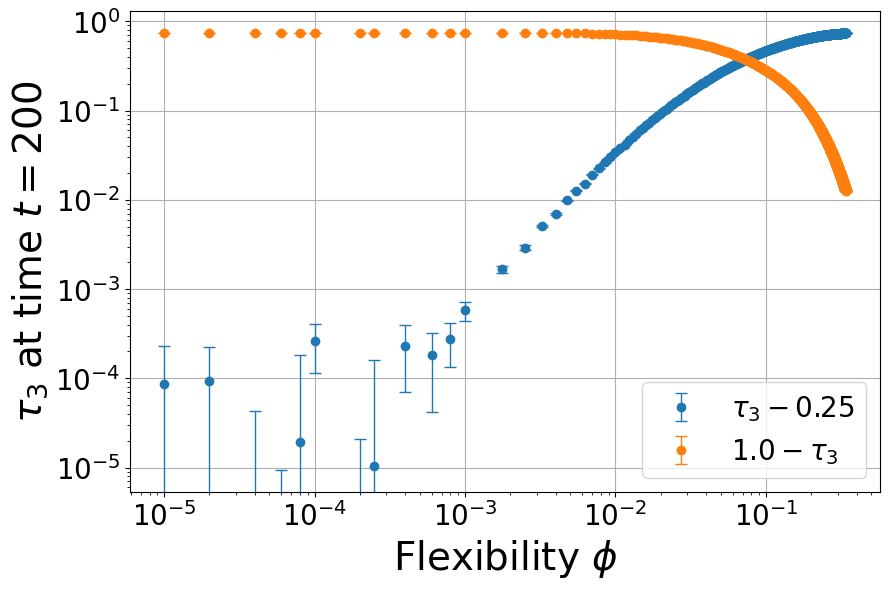

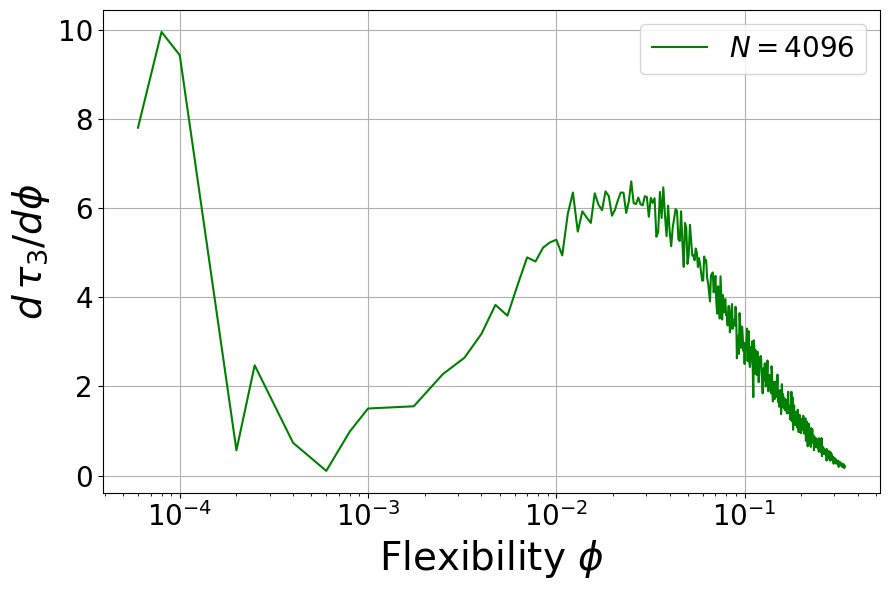

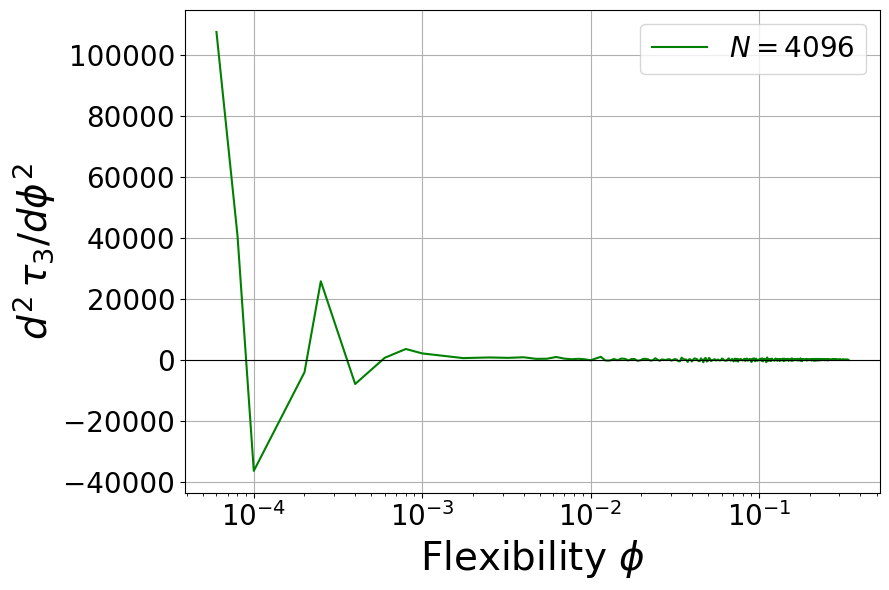

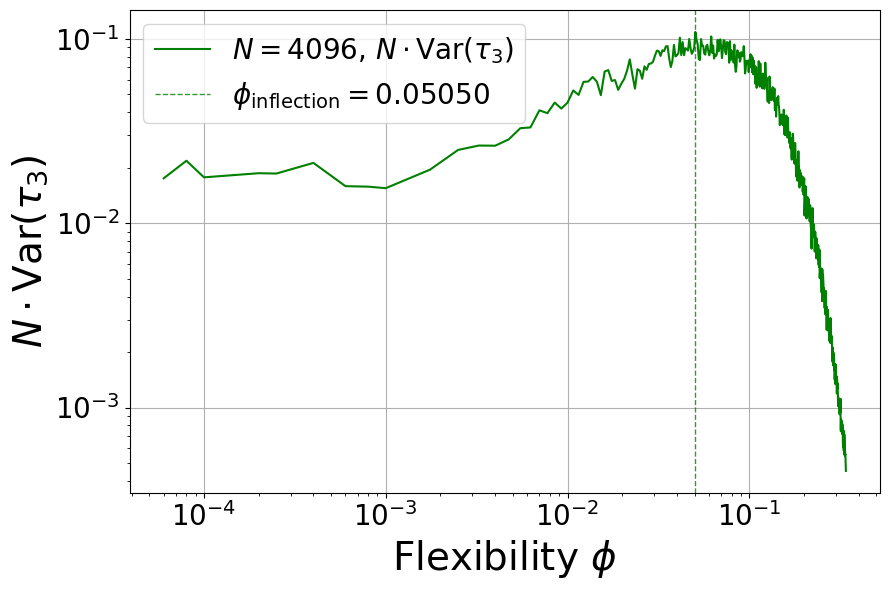

Power-law R^2 (log-log) = 0.9926
Sigmoid R^2 = 0.9989


c:\Users\audso\GitHub\DHT-simulations-misinformation-propagation\plot_phases.py:522: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((0,6000))


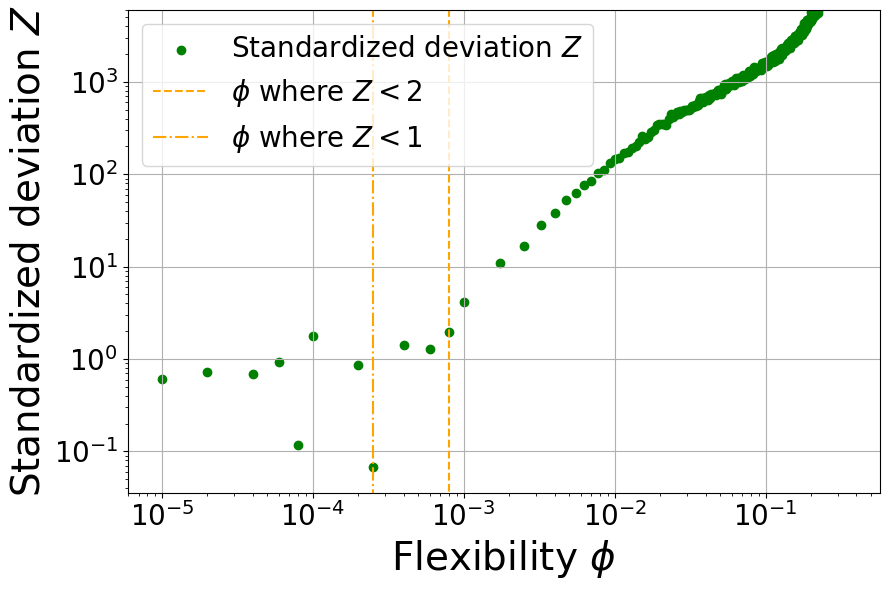

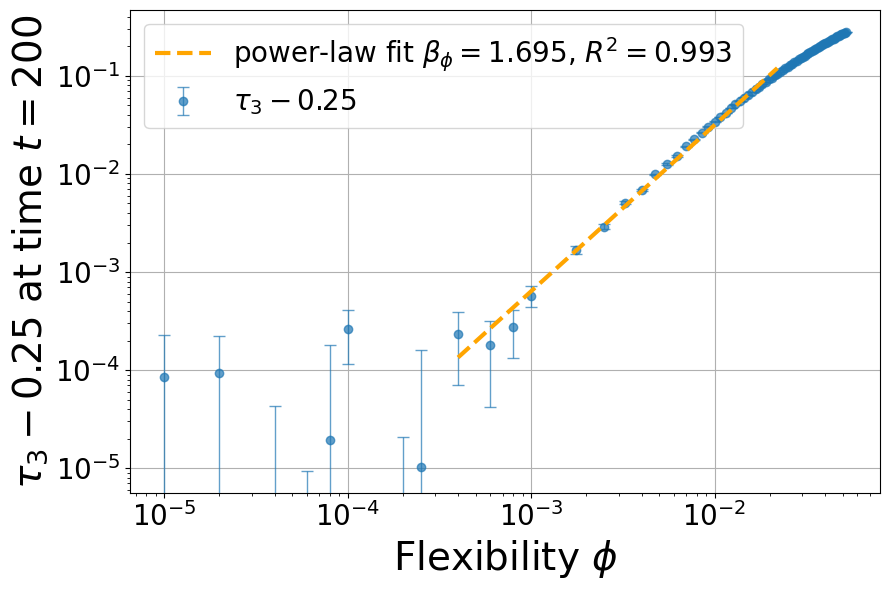

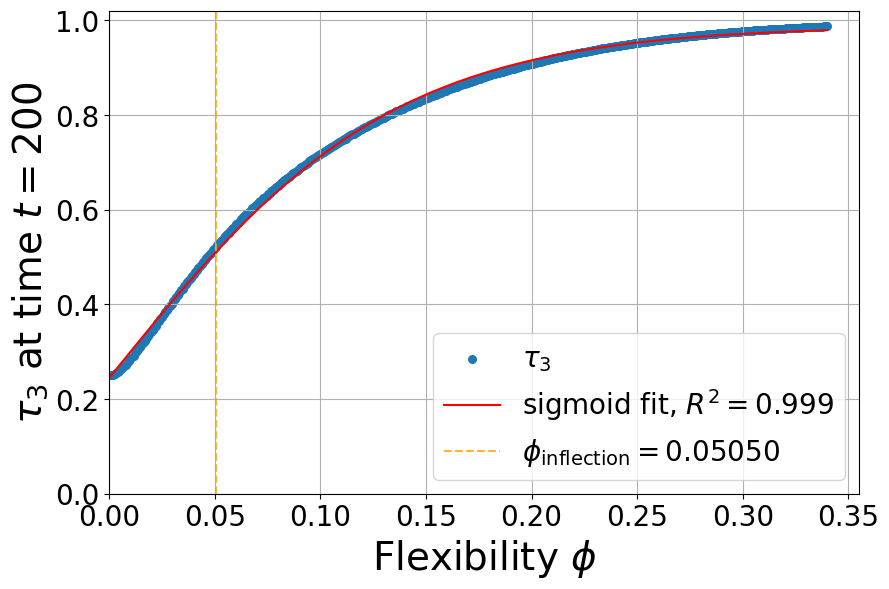

In [2]:
df = pd.read_csv("summary_flex-phase_final.csv")
dfs = [df]
N = [4096]

metrics = ["T0", "T1", "T2", "T3"]
metric="T3"
plot_phase_line(df, "F", metric, Path(f"phase_lines_{metric}.png"), Path("plots"), "log", "log", inverse=False)
plot_phase_derivatives(dfs, "F", metric, N, Path(f"phase_derivatives"), Path("plots"))
plot_power_law(df, "F", metric, Path(f"power_law_{metric}"), Path("plots"))

0.00175


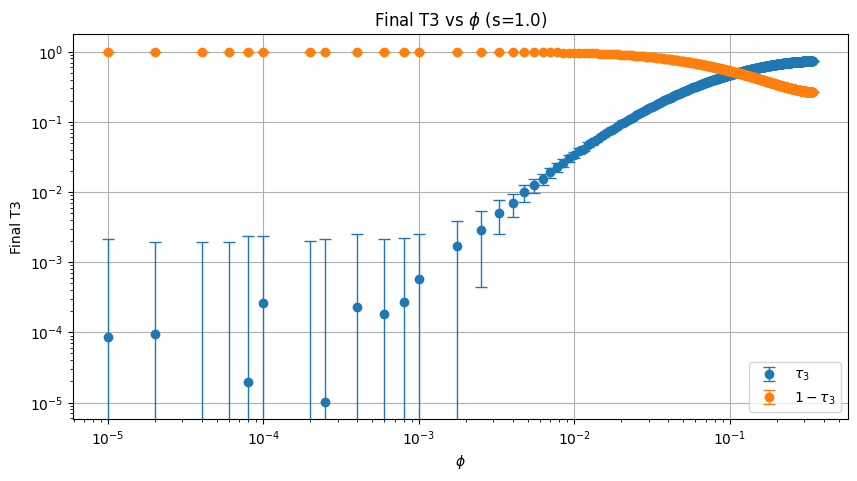

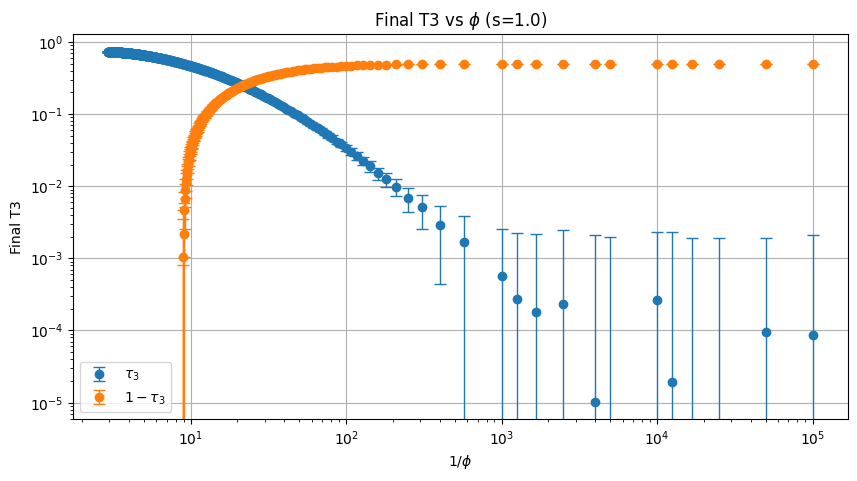

[-1.06352784 -0.86585894  0.4328774   1.20446372  0.49644305 -0.11176793
 -0.01265453  0.07879236 -0.02444979  0.00194167  0.01072334  0.0062971 ] [-0.99428571 -0.98857143 -0.97714286 -0.96571429 -0.95428571 -0.94285714
 -0.88571429 -0.85714286 -0.77142857 -0.65714286 -0.54285714 -0.42857143]


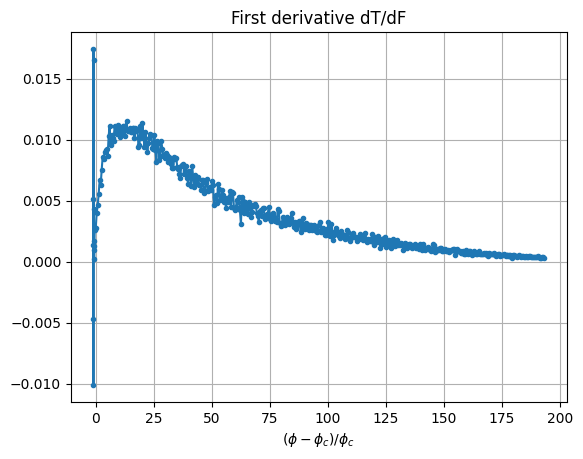

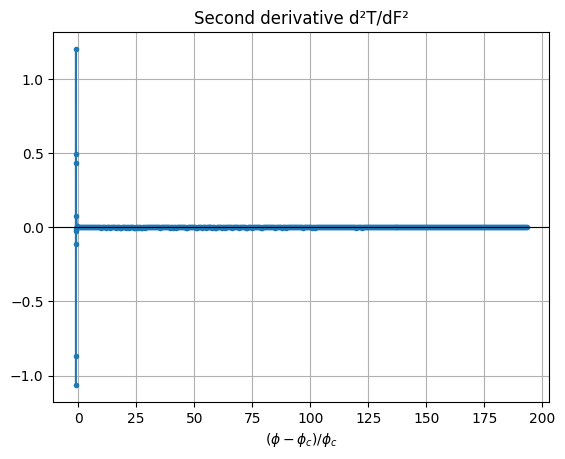

Critical F  = 0.000001
R²          = 0.998893
[ 1.48050067e+01  1.00000000e-06 -4.99195785e-01  9.88906736e-01]
First ten F-values: [1.0e-05 2.0e-05 4.0e-05 6.0e-05 8.0e-05 1.0e-04 2.0e-04 2.5e-04 4.0e-04
 6.0e-04]
First ten T-values: [ 8.61705509e-05  9.39324771e-05 -9.89083091e-05 -1.36841218e-04
  1.93859934e-05  2.61655926e-04 -1.30185385e-04  1.03033414e-05
  2.31357857e-04  1.81015992e-04]
gamma = 1.8
power law Fc = 0.001274900502728215


C:\Users\audso\AppData\Local\Temp\ipykernel_6500\1389563281.py:186: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((0,6000))


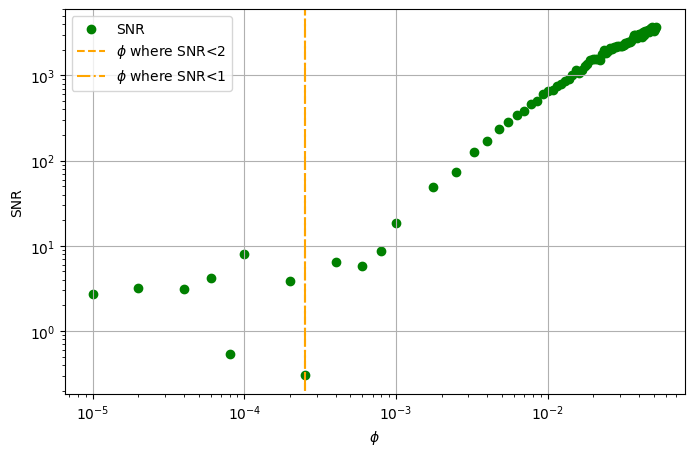

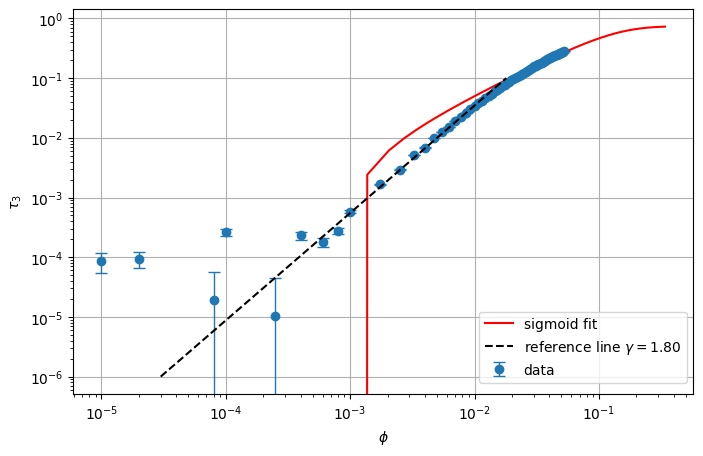

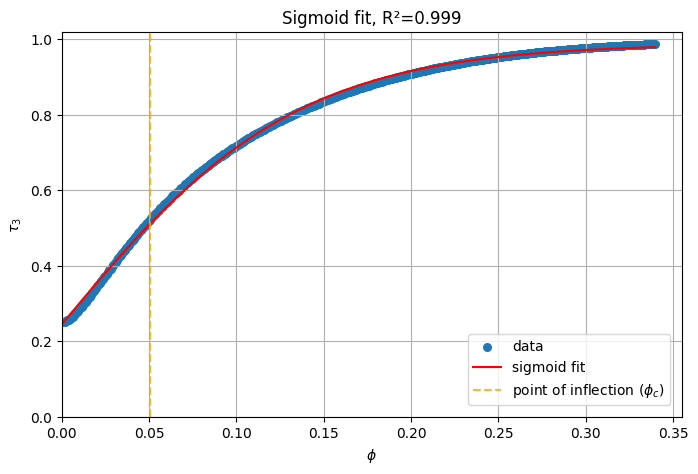

Critical exponent β = 0.1634732303316921


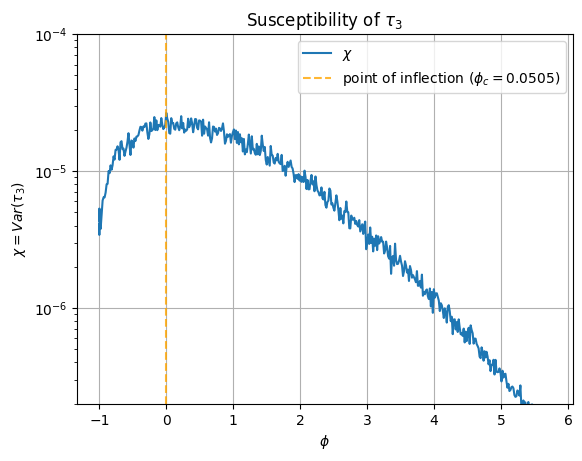

In [5]:
# Load your final summary (update path if needed)
df = pd.read_csv("summary_flex-phase_final.csv")

s_val = 1.0
df_flex = df[df['S'] == s_val].copy()

# Sort by S for a clean plot
df_flex = df_flex.sort_values("F")
F = df_flex["F"].values
# Fc=F[np.argmax(df_flex["T3_std"]**2)]
Fc=F[12]
print(Fc)

# Choose final truthfulness metric: T0, T1, T2, T3
metric = "T3"
std = metric + "_std"

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["F"], df_flex[metric], marker="o")
plt.errorbar(df_flex["F"], df_flex[metric]-0.25, df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(df_flex["F"], 1-df_flex[metric]+0.25, df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel(r"$\phi$")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.semilogx()
plt.ylabel(f"Final {metric}")
plt.title(fr"Final {metric} vs $\phi$ (s={s_val})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["F"], df_flex[metric], marker="o")
plt.errorbar(1/df_flex["F"], df_flex[metric]-0.25, df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(1/df_flex["F"], 1-df_flex[metric]-0.25, df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel(r"$1/\phi$")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.semilogx()
plt.ylabel(f"Final {metric}")
plt.title(fr"Final {metric} vs $\phi$ (s={s_val})")
plt.grid(True)
plt.legend()
plt.show()

f_all = (df_flex["F"].values - Fc) / Fc
dT3 = np.gradient(df_flex[metric], f_all)
d2T3 = np.gradient(dT3, f_all)
print(d2T3[:12], f_all[:12])
plt.figure()
plt.plot(f_all, dT3, '.-')
plt.title("First derivative dT/dF")
plt.xlabel(r"$(\phi-\phi_c)/\phi_c$")
plt.grid()
plt.show()

plt.figure()
plt.plot(f_all, d2T3, '.-')
plt.axhline(0, color='k', linewidth=0.8)
plt.title("Second derivative d²T/dF²")
plt.xlabel(r"$(\phi-\phi_c)/\phi_c$")
plt.grid()
plt.show()

def sigmoid(F, a, Fc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(F - Fc)))

def sqrt(F, a, Fc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow)*a*np.sqrt(F)

def log(F, a, Fc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow)*a*np.log((F) )

def exp_sat_shifted(F, a, Fc, Tlow, Thigh):
    x = np.maximum(F - Fc, 0.0) 
    return Tlow + (Thigh - Tlow) * (1 - np.exp(-a*X))

def hill(F, n, Fc, Tlow, Thigh):
    x = np.maximum(F - Fc, 0.0)
    return Tlow + (Thigh - Tlow) * (F**n) / (Fc**n + F**n)

def strexp(F, a, b, Tlow, Thigh):
    # F must be >= 0; a,b > 0
    return Tlow + (Thigh - Tlow) * (1 - np.exp(- (F / a)**b))

def gompertz(F, b, c, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) * np.exp(-b * np.exp(-c * F))

def concave_saturation(s, k, p, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) * (1 - (1 + k*s)**(-p))

def main_branch(F, k, p, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) * (1 - (1 + k*F)**(-p))

def double_sigmoid(F, A1, a1, Fc1, A2, a2, Fc2, T0):
    return (T0
            + A1 / (1 + np.exp(-a1 * (F - Fc1)))
            + A2 / (1 + np.exp(-a2 * (F - Fc2))))

def powerlaw(F, gamma, Fc, Tlow, Thigh):
    x = np.maximum(F - Fc, 0.0)
    return Tlow + (Thigh - Tlow) * (x)**gamma


F = df_flex["F"].values
T = df_flex[metric].values

# T0_guess  = T.min()
# A1_guess  = (T.max() - T.min()) * 0.9
# A2_guess  = (T.max() - T.min()) * 0.1
# Fc1_guess = 0.03   # around the big peak in dT/dF
# Fc2_guess = 0.25   # somewhere in the tail
# a1_guess  = 100.0
# a2_guess  = 50.0

# p0 = [A1_guess, a1_guess, Fc1_guess,
#       A2_guess, a2_guess, Fc2_guess,
#       T0_guess]

# params, cov = curve_fit(double_sigmoid, F, T, p0=p0, maxfev=50000)

p0 = [2.0, 0.1, np.min(T), np.max(T)] 
bounds = (
    [0.0001, 1e-6, -np.inf, -np.inf],
    [1000.0, 1.0, np.inf, np.inf]
)

params, cov = curve_fit(sigmoid, F, T, p0=p0, bounds=bounds, maxfev=50000)

Fpower = F[11:30]
Tpower = T[11:30]

powerparams, powercov = curve_fit(powerlaw, Fpower, Tpower, p0=[1.0, 1e-5, np.min(T), np.max(T)], bounds=bounds, maxfev=50000)

# Fit
a, Fc, Tlow, Thigh = params
gamma, Fc_power, Tlow_power, Thigh_power = powerparams

# Predictions
T_pred = sigmoid(F, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical F  = {Fc:.6f}")
# print(f"Sharpness a = {a:.6f}")
# print(f"Tlow        = {Tlow:.6f}")
# print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")
print(params)

F_sorted = np.linspace(min(F), max(F), 500)
f = (F-Fc)/Fc
f_sorted = (F_sorted - Fc) / Fc
T_fit_curve = sigmoid(F_sorted, *params)

Fpower_sorted = np.linspace(min(Fpower), max(Fpower), 500)
f_power = (Fpower - Fc_power) / Fc_power
f_power_sorted = (Fpower_sorted - Fc_power) / Fc_power
T_power_fit_curve = powerlaw(Fpower_sorted, *powerparams)

F_ref0 = 1.8e-2
T_ref0 = 1e-1
gamma = 1.8
F_ref = np.linspace(3e-5, F_ref0, 100)
T_ref = T_ref0 * (F_ref/F_ref0)**gamma

SEM = df_flex[std][:80]/np.sqrt(4000)
SNR = abs(T[:80]-0.25)/SEM

print(f"First ten F-values: {F[:10]}")
print(f"First ten T-values: {T[:10]-0.25}")

print(f"gamma =", gamma)
print(f"power law Fc =", Fc_power)

plt.figure(figsize=(8,5))
plt.scatter(F[:80], SNR, label="SNR", color='green')
plt.vlines(F[np.where(SNR<2)[0][-1]], ymin=0, ymax=10000, color='orange', linestyle="dashed", label=r"$\phi$ where SNR<2")
plt.vlines(F[np.where(SNR<1)[0][-1]], ymin=0, ymax=10000, color='orange', linestyle="dashdot", label=r"$\phi$ where SNR<1")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim((0,6000))
plt.xlabel(r"$\phi$")
plt.ylabel("SNR")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
# plt.scatter(F[:80], T[:80]-0.25, label="data", s=30)
# plt.scatter(F[:80], SNR, label="SNR", color='green')
# plt.vlines(F[np.where(SNR<2)[0][-1]], ymin=0, ymax=10000, color='orange', linestyle="dashed", label=r"$\phi$ where SNR<2")
# plt.vlines(F[np.where(SNR<1)[0][-1]], ymin=0, ymax=10000, color='orange', linestyle="dashdot", label=r"$\phi$ where SNR<1")
plt.errorbar(F[:80], (T[:80]-0.25), SEM, fmt='o', capsize=4, elinewidth=1, label=r"data")
plt.plot(F_sorted, T_fit_curve-0.25, 'r-', label="sigmoid fit")
plt.plot(F_ref, T_ref, label=fr"reference line $\gamma=${gamma:.2f}", color='black', linestyle='--', zorder=10)
# plt.plot(Fpower_sorted, T_power_fit_curve-0.25, 'g--', label=fr"power-law fit $\gamma=${gamma:.2f}")#, linestyle="dashed")
# plt.vlines(F[np.argmax(df_flex["T3_std"]**2)], ymin=0.0, ymax=1.02, color="orange", linestyles="dashed", alpha=0.8, label=r"point of inflection ($\phi_c$)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\tau_3$")
# plt.title(f"Sigmoid fit, R²={R2:.3f}")
plt.legend(loc=(0.655,0.03))
# plt.ylim((0.0, 1.02))
# plt.xlim((0, 0.355))
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(F, T, label="data", s=30)
plt.plot(F_sorted, T_fit_curve, 'r-', label="sigmoid fit")#, linestyle="dashed")
plt.vlines(F[np.argmax(df_flex["T3_std"]**2)], ymin=0.0, ymax=1.02, color="orange", linestyles="dashed", alpha=0.8, label=r"point of inflection ($\phi_c$)")
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\tau_3$")
plt.title(f"Sigmoid fit, R²={R2:.3f}")
plt.legend(loc=(0.655,0.03))
plt.ylim((0.0, 1.02))
plt.xlim((0, 0.355))
plt.grid()
plt.show()

Fc=df_flex["F"][np.argmax(df_flex["T3_std"]**2)]
mask = df_flex["F"] > Fc  # one side of transition
Ffit = df_flex["F"][mask]
Tfit = df_flex[metric][mask]
f = (Ffit - Fc) / Fc

logF = np.log(f)
logT = np.log(Tfit)
coef = np.polyfit(logF, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
# print("Critical exponent alpha =", 1/Fc)
f_all = (df_flex["F"].values - Fc) / Fc

plt.figure()
plt.plot(f_all, df_flex["T3_std"]**2, label=r"$\chi$")
# plt.xscale("log")
plt.vlines(f_all[np.argmax(df_flex["T3_std"]**2)], ymin=2e-7, ymax=1e-4, color="orange", linestyles="dashed", alpha=0.8, label=fr"point of inflection ($\phi_c = {F[np.argmax(df_flex['T3_std']**2)]}$)")
plt.ylabel(r"$\chi = Var(\tau_3)$")
plt.xlabel(r"$\phi$")
plt.yscale("log")
# plt.xlim((0, 0.355))
plt.ylim((2e-7, 1e-4))
plt.grid()
plt.legend()
plt.title(r"Susceptibility of $\tau_3$")
plt.show()

406 406
Critical exponent N4096 β = 0.2031088899417191
Critical exponent N1024 β = 0.1386909823652208
Critical exponent N256  β = 0.12486484117397958
Point of inflection N4096 $\phi_c$ = 0.0355
Point of inflection N1024 $\phi_c$ = 0.06325
Point of inflection N256 $\phi_c$ = 0.0715


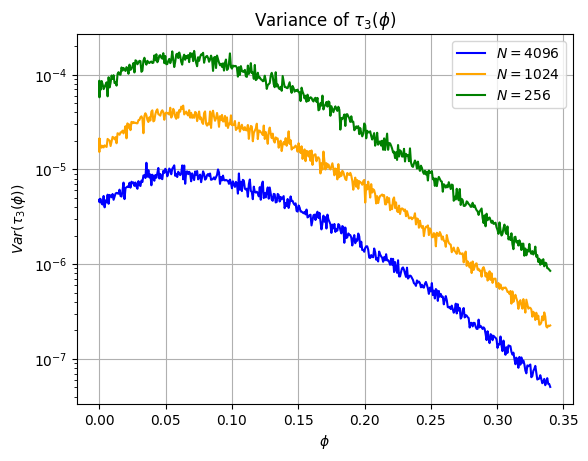

In [6]:
df4096 = pd.read_csv("summary_flex-phase_final_N4096.csv")
df1024 = pd.read_csv("summary_flex-phase_final_N1024.csv")
df256 = pd.read_csv("summary_flex-phase_final_N256.csv")

s_val = 1.0
df4096_flex = df4096[df4096['S'] == s_val].copy()
df1024_flex = df1024[df1024['S'] == s_val].copy()
df256_flex = df256[df256['S'] == s_val].copy()

# Sort by S for a clean plot
df4096_flex = df4096_flex.sort_values("F")
F4096 = df4096_flex["F"].values
Fc4096=F4096[np.argmax(df4096_flex["T3_std"]**2)]

df1024_flex = df1024_flex.sort_values("F")
F1024 = df1024_flex["F"].values
Fc1024=F1024[np.argmax(df1024_flex["T3_std"]**2)]

df256_flex = df256_flex.sort_values("F")
F256 = df256_flex["F"].values
Fc256=F256[np.argmax(df256_flex["T3_std"]**2)]

mask4096 = F4096 > Fc4096  # one side of transition
Ffit4096 = F4096[mask4096]
Tfit4096 = df4096_flex[metric][mask4096]
f4096 = (Ffit4096 - Fc4096) / Fc4096

mask1024 = F1024 > Fc1024  # one side of transition
Ffit1024 = F1024[mask1024]
Tfit1024 = df1024_flex[metric][mask1024]
f1024 = (Ffit1024 - Fc1024) / Fc1024

mask256 = F256 > Fc256  # one side of transition
Ffit256 = F256[mask256]
Tfit256 = df256_flex[metric][mask256]
f256 = (Ffit256 - Fc256) / Fc256

logF4096 = np.log(f4096)
logT4096 = np.log(Tfit4096)
print(len(logF4096), len(logT4096))
coef4096 = np.polyfit(logF4096, logT4096, 1)
beta4096 = coef4096[0]
logF1024 = np.log(f1024)
logT1024 = np.log(Tfit1024)
coef1024 = np.polyfit(logF1024, logT1024, 1)
beta1024 = coef1024[0]
logF256 = np.log(f256)
logT256 = np.log(Tfit256)
coef256 = np.polyfit(logF256, logT256, 1)
beta256 = coef256[0]

print("Critical exponent N4096 β =", beta4096)
print("Critical exponent N1024 β =", beta1024)
print("Critical exponent N256  β =", beta256)
print(fr"Point of inflection N4096 $\phi_c$ = {Fc4096}")
print(fr"Point of inflection N1024 $\phi_c$ = {Fc1024}")
print(fr"Point of inflection N256 $\phi_c$ = {Fc256}")

f4096_all = (F4096 - Fc4096) / Fc4096
f1024_all = (F1024 - Fc1024) / Fc1024
f256_all = (F256 - Fc256) / Fc256

plt.figure()
# plt.plot(f4096_all, df4096_flex["T3_std"]**2, label=r"$N=4096$", color="blue")
# plt.plot(f1024_all, df1024_flex["T3_std"]**2, label=r"$N=1024$", color="orange")
# plt.plot(f256_all, df256_flex["T3_std"]**2, label=r"$N=256$", color="green")
plt.plot(F4096, df4096_flex["T3_std"]**2, label=r"$N=4096$", color="blue")
plt.plot(F1024, df1024_flex["T3_std"]**2, label=r"$N=1024$", color="orange")
plt.plot(F256, df256_flex["T3_std"]**2, label=r"$N=256$", color="green")
# plt.vlines(F4096[np.argmax(df4096_flex["T3_std"]**2)], ymin=5e-8, ymax=3e-4, color="blue", linestyles="dashed", alpha=0.5, label=fr"$N=4096$ $\phi_c = {F4096[np.argmax(df4096_flex['T3_std']**2)]}$")
# plt.vlines(F1024[np.argmax(df1024_flex["T3_std"]**2)], ymin=5e-8, ymax=3e-4, color="orange", linestyles="dashed", alpha=0.5, label=fr"$N=1024$ $\phi_c = {F1024[np.argmax(df1024_flex['T3_std']**2)]}$")
# plt.vlines(F256[np.argmax(df256_flex["T3_std"]**2)], ymin=5e-8, ymax=3e-4, color="green", linestyles="dashed", alpha=0.5, label=fr"$N=256$ $\phi_c = {F256[np.argmax(df256_flex['T3_std']**2)]}$")
plt.ylabel(r"$Var(\tau_3(\phi))$")
plt.xlabel(r"$\phi$")
plt.yscale("log")
# plt.xscale("log")
# plt.xlim((0, 0.355))
# plt.ylim((5e-8, 3e-4))
plt.grid()
plt.legend()
plt.title(r"Variance of $\tau_3(\phi)$")
plt.show()

In [1]:
start = 0.005
end = 0.35
# n = 401
# step = (end - start) / (n - 1)
step = 0.00075
n = int((end - start) / step + 1)
S_values = [round(start + i * step, 5) for i in range(n)]
print(len(S_values))

460


[-1.47707347e+05 -1.42469381e+05 -1.63510756e+03  2.90346426e+04
 -1.16672437e+05 -1.35590858e+05  1.34342721e+01  5.27646837e+03
  1.15240793e+04  4.09487570e+02  1.99875513e+03  1.72364170e+03
  2.64065400e+02  7.61866203e+02  9.75406831e+02  5.54046163e+02
  3.11621122e+02  6.53387417e+02  4.75407426e+02  1.26908307e+02
  2.61472544e+02  3.83373116e+02  3.49344155e+02  8.89205213e+01
 -2.08883379e+02  1.84219607e+02  5.61835000e+02  3.01506728e+01
 -2.53571217e+02  3.70993288e+01] [1.000e-05 2.000e-05 4.000e-05 6.000e-05 8.000e-05 1.000e-04 2.000e-04
 2.500e-04 4.000e-04 6.000e-04 8.000e-04 1.000e-03 1.750e-03 2.500e-03
 3.250e-03 4.000e-03 4.750e-03 5.500e-03 6.250e-03 7.000e-03 7.750e-03
 8.500e-03 9.250e-03 1.000e-02 1.075e-02 1.150e-02 1.225e-02 1.300e-02
 1.375e-02 1.450e-02]


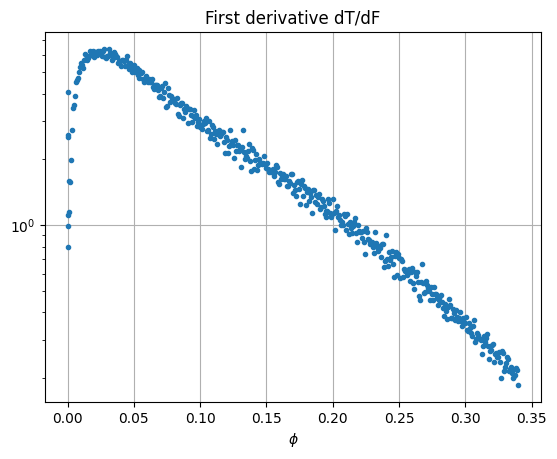

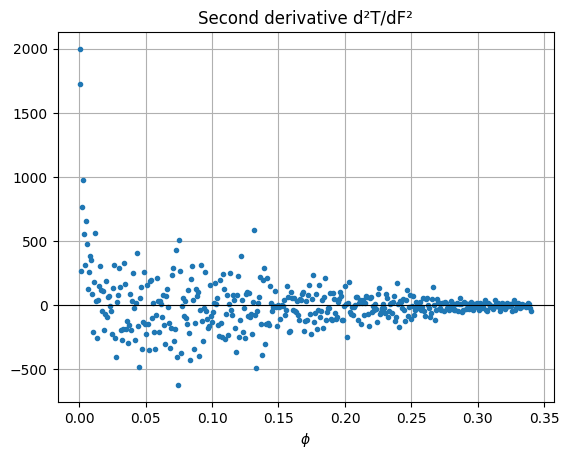

Point of inflection at flexibility strength=0.0008
Tail exponent $\gamma$ = -2.945025623283336e-05
-0.43149805238552463 0.213080715672395 2.176840473518528e-05


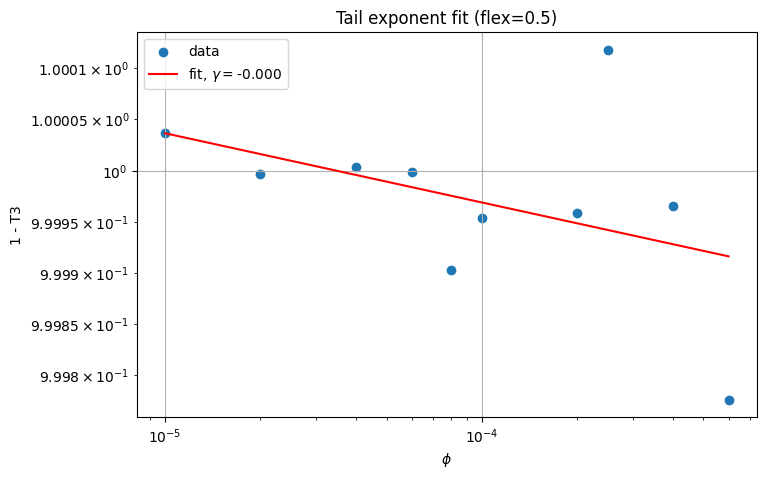

In [ ]:
import scipy as sp

df = pd.read_csv("summary_flex-phase_final_N4096.csv")
df_flex = df[df['S'] == 1.0].copy()
F = df_flex["F"].values
Fc=F[np.argmax(df_flex["T3_std"]**2)]
Fc=F[10] # 6 for 256, 9 for 1024, 12 for 4096

f_all = (df_flex["F"].values - Fc) / Fc
dT3 = np.gradient(df_flex[metric], F)
d2T3 = np.gradient(dT3, F)
print(d2T3[:30], F[:30])
plt.figure()
plt.plot(F, dT3, '.')
plt.title("First derivative dT/dF")
plt.xlabel(r"$\phi$")
# plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.show()

plt.figure()
plt.plot(F[10:], d2T3[10:], '.')
plt.axhline(0, color='k', linewidth=0.8)
plt.title("Second derivative d²T/dF²")
plt.xlabel(r"$\phi$")
# plt.xscale("log")
# plt.yscale("log")
plt.grid()
plt.show()

tail = df[df["F"] < Fc]
mask = df_flex["F"] < Fc
Ffit = df_flex["F"][mask]
X = np.log(Fc - Ffit)
Y = np.log(df_flex["T3_std"][mask]**2)
gamma = - np.polyfit(X, Y, 1)[0]
F_tail = tail["F"].values
f_tail = (F_tail - Fc) / Fc
T3_tail = tail["T3"].values
one_minus_T3 = 1 - T3_tail

# --- log-log fit of tail ---
x = np.log(F_tail)
y = np.log(one_minus_T3+0.25)

slope, intercept, r_value, p_value, std_err = sp.stats.linregress(x, y)
gamma = slope

# --- predicted line ---
xfit = np.linspace(min(x), max(x), 200)
yfit = gamma * xfit + intercept

print(fr"Point of inflection at flexibility strength={Fc}")
print(r"Tail exponent $\gamma$ =", gamma)
print(r_value, p_value, std_err)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.scatter(F_tail, one_minus_T3+0.25, label="data")
plt.plot(np.exp(xfit), np.exp(yfit), 'r-', label=fr"fit, $\gamma =${gamma:.3f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\phi$")
plt.ylabel("1 - T3")
plt.title("Tail exponent fit (flex=0.5)")
plt.grid(True)
plt.legend()
plt.show()

Critical F  = 999.999992
R²          = 0.999975
[ 2.42654817e-01  4.89084188e+01  2.86860057e-02  9.03726888e-01
  1.33651292e+01  4.05057780e-02 -1.42683551e-01]


NameError: name 'T1' is not defined

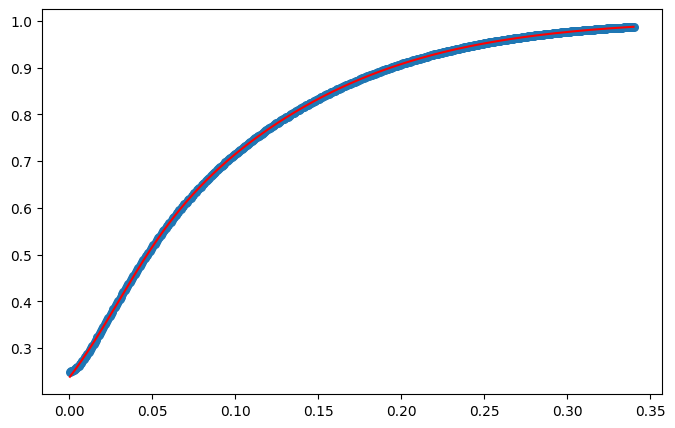

In [ ]:
def sigmoid(F, a, Fc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(F )))

def sqrt(F, a, Fc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow)*a*np.sqrt(F)

def log(F, a, Fc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow)*a*np.log((F) )

def exp_sat_shifted(F, a, Fc, Tlow, Thigh):
    x = np.maximum(F - Fc, 0.0) 
    return Tlow + (Thigh - Tlow) * (1 - np.exp(-a*X))

def hill(F, n, Fc, Tlow, Thigh):
    x = np.maximum(F - Fc, 0.0)
    return Tlow + (Thigh - Tlow) * (F**n) / (Fc**n + F**n)

def strexp(F, a, b, Tlow, Thigh):
    # F must be >= 0; a,b > 0
    return Tlow + (Thigh - Tlow) * (1 - np.exp(- (F / a)**b))

def gompertz(F, b, c, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) * np.exp(-b * np.exp(-c * F))

def concave_saturation(s, k, p, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) * (1 - (1 + k*s)**(-p))

def main_branch(F, k, p, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) * (1 - (1 + k*F)**(-p))

def double_sigmoid(F, A1, a1, Fc1, A2, a2, Fc2, T0):
    return (T0
            + A1 / (1 + np.exp(-a1 * (F - Fc1)))
            + A2 / (1 + np.exp(-a2 * (F - Fc2))))


F = df_flex["F"].values
T = df_flex[metric].values

T0_guess  = T.min()
A1_guess  = (T.max() - T.min()) * 0.9
A2_guess  = (T.max() - T.min()) * 0.1
Fc1_guess = 0.03   # around the big peak in dT/dF
Fc2_guess = 0.25   # somewhere in the tail
a1_guess  = 100.0
a2_guess  = 50.0

p0 = [A1_guess, a1_guess, Fc1_guess,
      A2_guess, a2_guess, Fc2_guess,
      T0_guess]

params, cov = curve_fit(double_sigmoid, F, T, p0=p0, maxfev=50000)

# p0 = [2.0, 10.0, np.min(T), np.max(T)] 
# bounds = (
#     [0.0001, 0.0001, -np.inf, -np.inf],
#     [1000.0, 1000.0, np.inf, np.inf]
# )

# params, cov = curve_fit(concave_saturation, F, T, p0=p0, bounds=bounds, maxfev=50000)

# # Fit
# a, Fc, Tlow, Thigh = params

# Predictions
T_pred = double_sigmoid(F, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical F  = {Fc:.6f}")
# print(f"Sharpness a = {a:.6f}")
# print(f"Tlow        = {Tlow:.6f}")
# print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")
print(params)

F_sorted = np.linspace(min(F), max(F), 500)
f = (F-Fc)/Fc
f_sorted = (F_sorted - Fc) / Fc
T_fit_curve = double_sigmoid(F_sorted, *params)

plt.figure(figsize=(8,5))
plt.scatter(F, T, label="data", s=30)
plt.plot(F_sorted, T_fit_curve, 'r-', label="sigmoid fit")#, linestyle="dashed")
plt.vlines(F[np.argmax(df_flex["T3_std"]**2)], ymin=0.24, ymax=1.02, color="orange", linestyles="dashed", alpha=0.8, label=r"point of inflection ($\phi_c$)")
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\tau_3$")
plt.title(f"Sigmoid fit, R²={R2:.3f}")
plt.legend(loc=(0.655,0.03))
plt.ylim((0.0, 1.02))
plt.xlim((0, 0.355))
plt.grid()
plt.show()

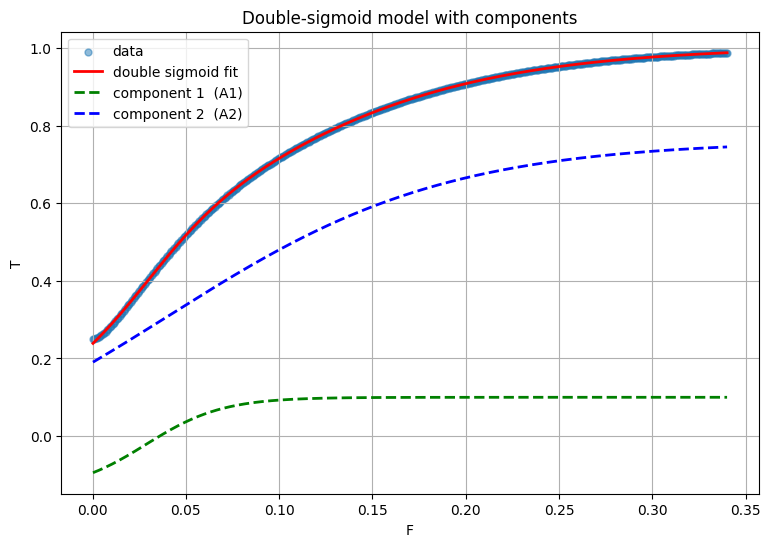

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Model definitions
# -----------------------------

def sigmoid_component(F, A, a, Fc):
    return A / (1 + np.exp(-a * (F - Fc)))

def double_sigmoid(F, A1, a1, Fc1, A2, a2, Fc2, T0):
    T1 = sigmoid_component(F, A1, a1, Fc1)
    T2 = sigmoid_component(F, A2, a2, Fc2)
    return T0 + T1 + T2, T1, T2


# -----------------------------
# 2. Your fitted parameters
# -----------------------------

A1 = 2.42654817e-01
a1 = 4.89084188e+01
Fc1 = 2.86860057e-02

A2 = 9.03726888e-01
a2 = 1.33651292e+01
Fc2 = 4.05057780e-02

T0 = -1.42683551e-01

params = [A1, a1, Fc1, A2, a2, Fc2, T0]


# -----------------------------
# 3. Generate curves
# -----------------------------

F = df_flex["F"].values
T = df_flex[metric].values

F_sorted = np.linspace(min(F), max(F), 1000)

T_full, T1, T2 = double_sigmoid(F_sorted, *params)


# -----------------------------
# 4. Plot everything
# -----------------------------

plt.figure(figsize=(9,6))

# Data
plt.scatter(F, T, s=25, alpha=0.5, label="data")

# Full double-sigmoid model
plt.plot(F_sorted, T_full, 'r-', linewidth=2, label="double sigmoid fit")

# Component sigmoids
plt.plot(F_sorted, T1 + T0, 'g--', linewidth=2,
         label="component 1  (A1)")
plt.plot(F_sorted, T2 + T0, 'b--', linewidth=2,
         label="component 2  (A2)")

# For clarity, also plot the raw components (without T0)
# (Uncomment if needed)
# plt.plot(F_sorted, T1, 'g:', label="T1 (no offset)")
# plt.plot(F_sorted, T2, 'b:', label="T2 (no offset)")

plt.xlabel("F")
plt.ylabel("T")
plt.title("Double-sigmoid model with components")
plt.grid(True)
plt.legend()
plt.show()


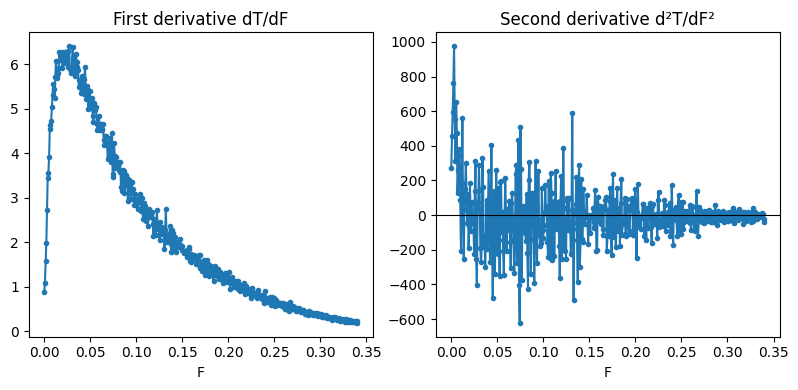

In [ ]:
F = df_flex["F"].values
T = df_flex[metric].values

# Make sure data are sorted by F
idx = np.argsort(F)
Fs = F[idx]
Ts = T[idx]

# Numerical first and second derivatives
dT_dF  = np.gradient(Ts, Fs)
d2T_dF2 = np.gradient(dT_dF, Fs)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(Fs, dT_dF, '.-')
plt.title("First derivative dT/dF")
plt.xlabel("F")

plt.subplot(1,2,2)
plt.plot(Fs, d2T_dF2, '.-')
plt.axhline(0, color='k', linewidth=0.8)
plt.title("Second derivative d²T/dF²")
plt.xlabel("F")

plt.tight_layout()
plt.show()


Critical exponent β = 0.33457888362896726
Critical exponent alpha = 28.169014084507044


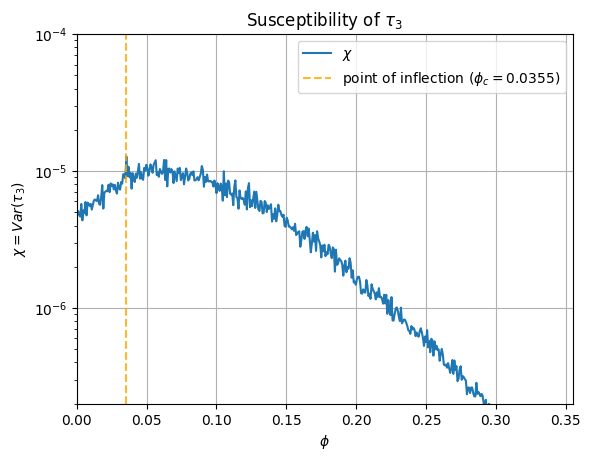

In [ ]:
mask = df_flex["S"] > Fc  # one side of transition
Sfit = df_flex["S"][mask]
Tfit = df_flex[metric][mask]
f = (Sfit - Fc) / Fc

logF = np.log(F)
logT = np.log(Tfit)

coef = np.polyfit(logF, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
print("Critical exponent alpha =", 1/0.0355)
f_all = (df_flex["F"].values - Fc) / Fc

plt.figure()
plt.plot(F, df_flex["T3_std"]**2, label=r"$\chi$")
# plt.xscale("log")
plt.vlines(F[np.argmax(df_flex["T3_std"]**2)], ymin=2e-7, ymax=1e-4, color="orange", linestyles="dashed", alpha=0.8, label=fr"point of inflection ($\phi_c = {F[np.argmax(df_flex['T3_std']**2)]}$)")
plt.ylabel(r"$\chi = Var(\tau_3)$")
plt.xlabel(r"$\phi$")
plt.yscale("log")
plt.xlim((0, 0.355))
plt.ylim((2e-7, 1e-4))
plt.grid()
plt.legend()
plt.title(r"Susceptibility of $\tau_3$")
plt.show()

In [ ]:
# Load your final summary (update path if needed)
df = pd.read_csv("combined_results/summary_s-phase_final2.csv")

# Filter for flex = 0.5
flex_val = 0.5
df_flex = df[df['F'] == flex_val].copy()

# Sort by S for a clean plot
df_flex = df_flex.sort_values("S")

# Choose final truthfulness metric: T0, T1, T2, T3
metric = "T3"
std = metric + "_std"

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("S")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(1/df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(1/df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("1/S")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

dT3 = np.gradient(df_flex[metric], df_flex["S"])
print(fr"The peak of $\nabla\tau_3(S)$ is at S = {df_flex['S'][np.argmax(dT3)]}")
plt.plot(df_flex["S"], np.abs(dT3))
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xlabel("S")
plt.ylabel(fr"$\nabla\tau_3(S)$")
plt.show()

def sigmoid(S, a, Sc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(S - Sc)))

S = df_flex["S"].values
T = df_flex[metric].values

p0 = [50, 0.3, min(T), max(T)]

# Fit
params, cov = curve_fit(sigmoid, S, T, p0=p0, maxfev=50000)
a, Sc, Tlow, Thigh = params

# Predictions
T_pred = sigmoid(S, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical S  = {Sc:.6f}")
print(f"Sharpness a = {a:.6f}")
print(f"Tlow        = {Tlow:.6f}")
print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")

S_sorted = np.linspace(min(S), max(S), 500)
T_fit_curve = sigmoid(S_sorted, *params)

plt.figure(figsize=(8,5))
plt.scatter(S, T, label="data")
plt.plot(S_sorted, T_fit_curve, 'r-', label="sigmoid fit")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("S")
plt.ylabel("T3 final")
plt.title(f"Sigmoid fit (flex=0.5), R²={R2:.3f}")
plt.legend()
plt.grid(True)
plt.show()

mask = df_flex["S"] > Sc  # one side of transition
Sfit = df_flex["S"][mask]
Tfit = df_flex[metric][mask]

logS = np.log(Sfit - Sc)
logT = np.log(Tfit)

coef = np.polyfit(logS, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
print("Critical exponent alpha =", 1/0.159999999999)

plt.plot(df_flex["S"], df_flex["T3_std"]**2)
plt.xscale("log")
plt.yscale("log")
plt.title("Susceptibility χ = Var(T3)")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'combined_results/summary_s-phase_final2.csv'

C:\Users\audso\AppData\Local\Temp\ipykernel_23984\3381247423.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


<Figure size 1000x670 with 0 Axes>

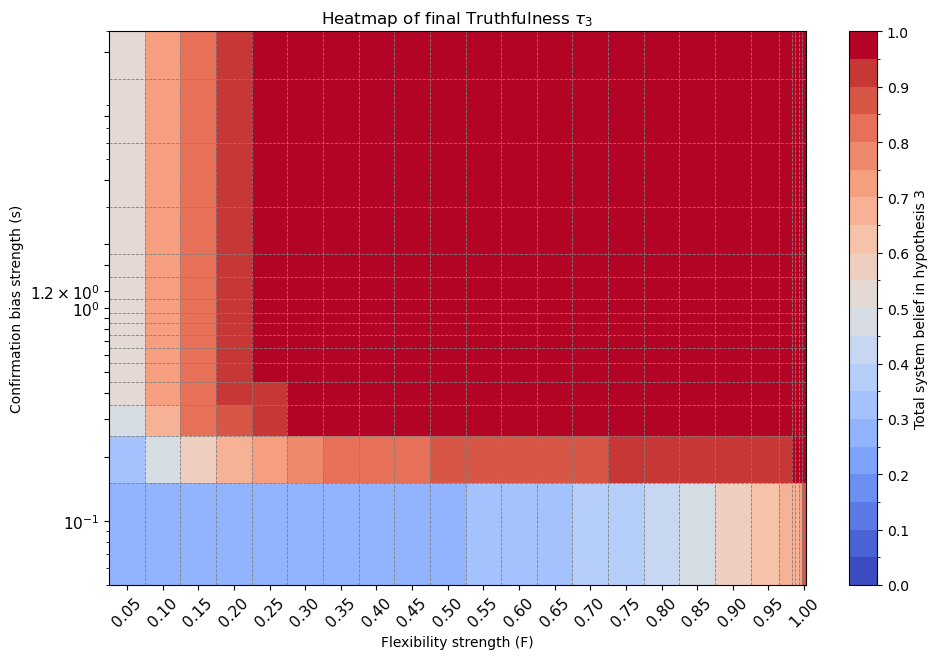

<Figure size 1000x670 with 0 Axes>

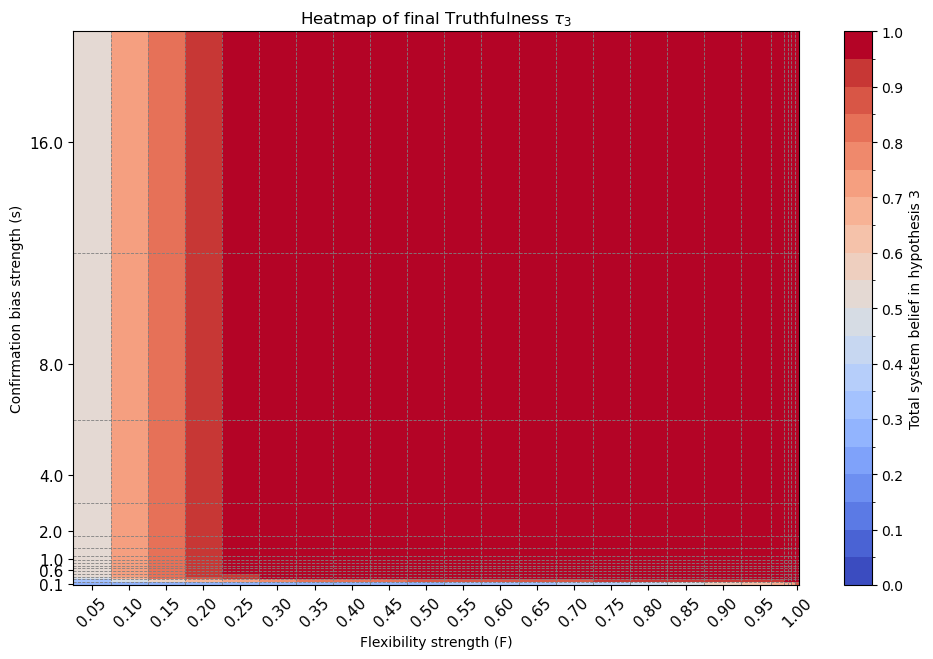

✅ Saved heatmap to plots\heatmap_T3.png


In [ ]:
data_path = Path("combined_results/summary_ba_final.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)
X, Y = np.meshgrid(FLEX_STRENGTH_values, S_values)

df = pd.read_csv(data_path)
metric = "T3" 
pivot = df.pivot(index="S", columns="F", values=metric)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

vmin, vmax = 0.0, 1.0
n_bins = 20
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

pivot = pivot.sort_index(axis=0, ascending=False).sort_index(axis=1)

def compute_edges(arr):
    arr = np.asarray(arr)
    edges = (arr[:-1] + arr[1:]) / 2
    edges = np.concatenate([[arr[0] - (edges[0] - arr[0])], edges, [arr[-1] + (arr[-1] - edges[-1])]])
    return edges
y_ticks = [0.1, 0.6, 1.0, 2, 4, 8, 16]

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")

ax.set_yscale('log')
plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap__logy_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")
plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
plt.yticks(y_ticks, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"✅ Saved heatmap to {out_path}")

Processing combined files: 100%|██████████| 384/384 [00:08<00:00, 47.18it/s]
C:\Users\audso\AppData\Local\Temp\ipykernel_33648\3342389618.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


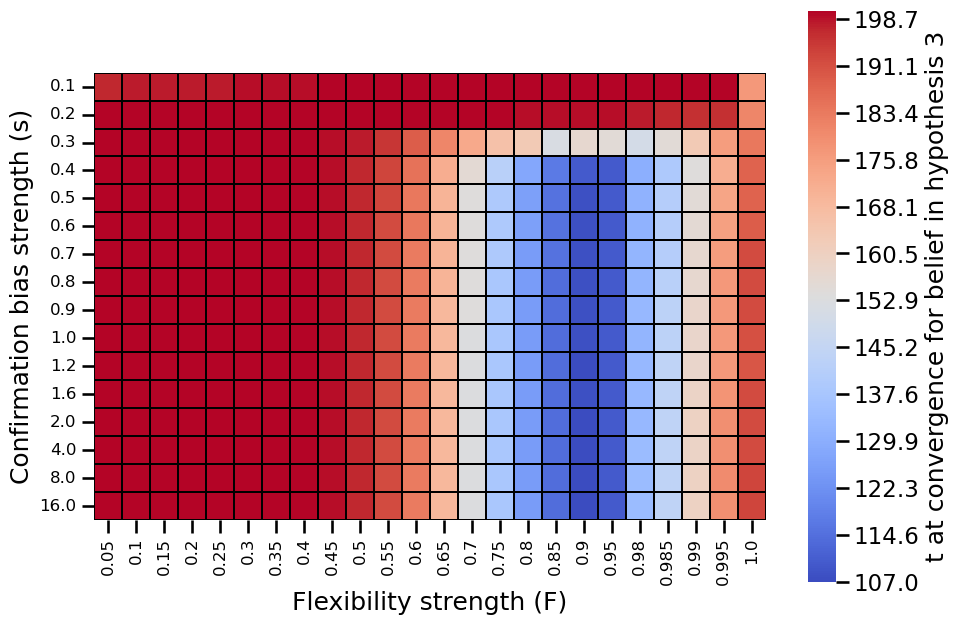

✅ Saved convergence heatmap to plots\convergence_heatmap_T3.png


In [ ]:
# === Configuration ===
data_root = Path("combined_results")
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

metric = "T3"          # change to T1, T2, T3, or CD as needed
threshold = 1e-4       # convergence criterion
n_bins = 10            # discrete color levels
vmin, vmax = 0, 200    # timestep range for color scale (adjust to your simulation length)

# === Load all combined files ===
files = list(data_root.glob("COMBINED_S*_F*.npz"))
rows = []

for f in tqdm(files, desc="Processing combined files"):
    data = np.load(f)
    S, F = data["S"].item(), data["F"].item()
    arr = data[metric]
    final_val = arr[-1]

    # find first timestep within threshold of final value
    diffs = np.abs(arr - final_val)
    conv_idx = np.argmax(diffs < threshold) if np.any(diffs < threshold) else len(arr) - 1
    rows.append({"S": S, "F": F, "converged_at": conv_idx})

# === Build DataFrame ===
df = pd.DataFrame(rows)
pivot = df.pivot(index="S", columns="F", values="converged_at")
pivot = pivot.sort_index(axis=0).sort_index(axis=1)

# === Fixed discrete colormap ===
vmin, vmax = 0.0, 200
n_bins = 200
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# === Plot ===
plt.figure(figsize=(10, 6.7))
sns.set_context("talk")

ax = sns.heatmap(
    pivot,
    cmap="coolwarm",
    vmin=np.min(df["converged_at"]),
    vmax=np.max(df["converged_at"]),
    # norm=norm,
    cbar_kws={
        "ticks": np.linspace(np.min(df["converged_at"]), 214, 15),
        "label": f"t at convergence for belief in hypothesis {metric[1]}",
    },
    linewidths=0.1,
    linecolor='black',
    square=True
)

# plt.title(f"Heatmap of {metric} (final timestep)")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
out_path = output_dir / f"convergence_heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()


print(f"✅ Saved convergence heatmap to {out_path}")
